In [70]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import matplotlib.pyplot as plt
%matplotlib inline
from prophet import Prophet
import plotly.graph_objects as go 
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet.plot import plot, plot_components
from prophet.diagnostics import cross_validation, performance_metrics
import datetime

/kaggle/input/samsung-electronics-stock-historical-price/005930.KS.csv
/kaggle/input/samsung-electronics-stock-historical-price/005930.KS_weekly.csv
/kaggle/input/samsung-electronics-stock-historical-price/005930.KS_monthly.csv


In [28]:
# import data
samsung_daily = pd.read_csv("/kaggle/input/samsung-electronics-stock-historical-price/005930.KS.csv")
samsung_weekly = pd.read_csv("/kaggle/input/samsung-electronics-stock-historical-price/005930.KS_weekly.csv")
samsung_monthly = pd.read_csv("/kaggle/input/samsung-electronics-stock-historical-price/005930.KS_monthly.csv")

In [29]:
samsung_daily.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-01-02,39400.0,39400.0,38550.0,38750.0,33776.164062,7847664
1,2019-01-03,38300.0,38550.0,37450.0,37600.0,32773.765625,12471493
2,2019-01-04,37450.0,37600.0,36850.0,37450.0,32643.021484,14108958
3,2019-01-07,38000.0,38900.0,37800.0,38750.0,33776.164062,12748997
4,2019-01-08,38000.0,39200.0,37950.0,38100.0,33209.582031,12756554


In [30]:
print(samsung_daily["Date"].min(), samsung_daily["Date"].max())

2019-01-02 2024-05-14


In [31]:
samsung_daily.shape

(1321, 7)

In [32]:
samsung_weekly.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-12-31,38700.0,39400.0,36850.0,38750.0,33776.164062,47177112.0
1,2019-01-07,38000.0,40700.0,37950.0,40050.0,34909.285156,68587020.0
2,2019-01-14,40050.0,42750.0,39850.0,42750.0,37262.722656,54106211.0
3,2019-01-21,42750.0,45500.0,41350.0,45050.0,39267.496094,76571367.0
4,2019-01-28,45050.0,47050.0,44350.0,46350.0,40400.644531,69174596.0


In [33]:
print(samsung_weekly["Date"].min(), samsung_weekly["Date"].max())

2018-12-31 2024-05-14


In [34]:
samsung_weekly.shape

(282, 7)

In [35]:
samsung_monthly.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-12-31,38700.0,47050.0,36850.0,46150.0,40226.312500,301783852
1,2019-01-31,46650.0,47550.0,44250.0,45100.0,39311.082031,194923203
2,2019-02-28,45100.0,47000.0,43100.0,44650.0,38918.843750,223260605
3,2019-03-31,45200.0,47600.0,43800.0,45850.0,40279.238281,209113436
4,2019-04-30,45850.0,46150.0,40850.0,42500.0,37336.257812,271585071


In [36]:
print(samsung_monthly["Date"].min(), samsung_monthly["Date"].max())

2018-12-31 2024-05-14


In [37]:
samsung_monthly.shape

(66, 7)

# EDA 

Do the EDA in the dataset

In [38]:
samsung_daily.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [39]:
samsung_weekly.isnull().sum()

Date         0
Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [40]:
samsung_monthly.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Since the data period is vary, and the data is updated daily, so weekly data could contain missing value because the incomplete period of daily data in a week. To fill the missing value, the missing value will be replaced by 0

In [41]:
samsung_weekly = samsung_weekly.fillna(0)

In [42]:
# open, high, low, close price of samsung stock price
fig1 = go.Figure(data=go.Ohlc(x=samsung_daily["Date"], 
                             open=samsung_daily["Open"], 
                             high=samsung_daily["High"], 
                             low=samsung_daily["Low"], 
                             close=samsung_daily["Close"], 
                             ))
fig1.update_layout(title="Daily OHLC Price of Samsung")

# show the figure
fig1.show()

From the plot above, we can see that the OHLC daily price of Samsung is very volatile

In [43]:
# plot the weekly data
fig2 = go.Figure(data=go.Ohlc(x=samsung_weekly["Date"], 
                             open=samsung_weekly["Open"], 
                             high=samsung_weekly["High"], 
                             low=samsung_weekly["Low"], 
                             close=samsung_weekly["Close"], 
                             ))
fig2.update_layout(title="Weekly OHLC Price of Samsung")

# show the figure
fig2.show()

From the plot above, we can see that the weekly OLHC price movement of Samsung has the same movement as daily movement

In [44]:
# plot the monthly data
fig3 = go.Figure(data=go.Ohlc(x=samsung_monthly["Date"], 
                             open=samsung_monthly["Open"], 
                             high=samsung_monthly["High"], 
                             low=samsung_monthly["Low"], 
                             close=samsung_monthly["Close"], 
                             ))
fig3.update_layout(title="Monthly OHLC Price of Samsung")

# show the figure
fig3.show()

From the plot above, we can see that the monthly OLHC price movement of Samsung has the same movement as daily movement

From all the plot, there are some patterns, like at the beginning of the year, the price goes up then goes down. To know more, lets decompose the detail

## Decomposing the daily series 

Decomposing is one way to knowing a time series data in detail. In decomposing, the trend, seasonal, additive effect could be detected. In this section, the decomposition will be done on daily, weekly, andd monthly data

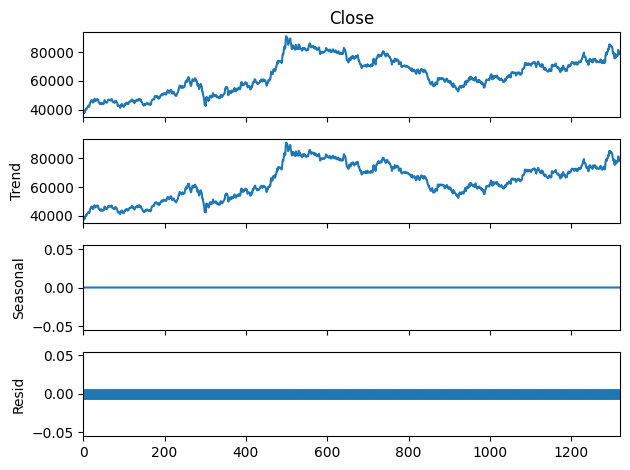

In [45]:
# additive method 
dailyadd = seasonal_decompose(samsung_daily["Close"], model="additive", period=1)
dailyadd.plot();

From the decomposition above, there are no seasonal trend. 

## Decomposing the weekly series 

In this section, the decomposition will be done on weekly data

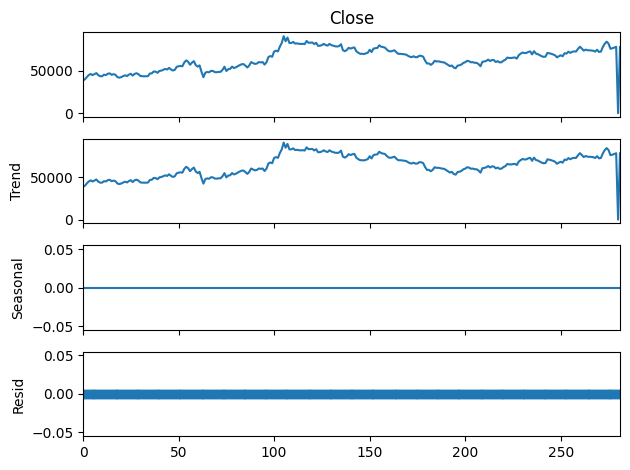

In [46]:
# additive method
weekadd = seasonal_decompose(samsung_weekly["Close"], model="additive", period=1)
weekadd.plot();

## Decomposing the monthly series 

In this section, the decomposition will be done on monthly data

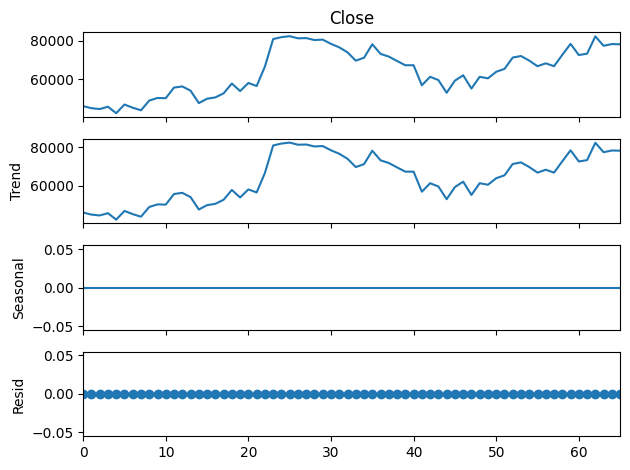

In [47]:
# additive method
monthadd = seasonal_decompose(samsung_monthly["Close"], model="additive", period=1)
monthadd.plot();

# Modelling 

In this section, the modelling will be done to predict the price of Samsung close price

In [48]:
# data for forecasting
dailyclose = samsung_daily[["Date", "Close"]].rename(columns={"Date" : "ds", "Close" : "y"})
weeklyclose = samsung_daily[["Date", "Close"]].rename(columns={"Date" : "ds", "Close" : "y"})
monthlyclose = samsung_daily[["Date", "Close"]].rename(columns={"Date" : "ds", "Close" : "y"})

# change the date into pandas date time format
dailyclose["ds"] = pd.to_datetime(dailyclose["ds"])
weeklyclose["ds"] = pd.to_datetime(dailyclose["ds"])
monthlyclose["ds"] = pd.to_datetime(dailyclose["ds"])

## Forecasting  

Prophet is a model created by Meta. This model used to forecasting in time series data. In this analysis, I
will forecast the close price of samsung stock price using prophet model. The data that will be forecasted is close price. For the forecast period, usually there are no rule of how long a good forecasting period. I will forecast the close price for the next 6 months with the detail as below :
* Daily : 120 days forward (with assumption of 20 days per month)
* Weekly : 24 weeks forward (with assumption of 4 weeks per month)
* Monthly : 6 months forward 

Prophet model with freq = "D" forecasts the data daily (everyday), but the stock is only traded in weekdays, so the forecasted value where the date is on weekend will be dropped

In [68]:
# define the model
model1 = Prophet()

# fit the mode;
model1.fit(dailyclose) 

# dataframe for forecast object
forecastdaily_df = model1.make_future_dataframe(periods=180, freq="D")

# forecast the close price
forecastdaily = model1.predict(forecastdaily_df)

# add the day column 
forecastdaily["day_name"] = forecastdaily["ds"].apply(lambda x: x.strftime('A%'))

# drop the date where the day is Saturday or Sunday
forecastdaily = forecastdaily[~forecastdaily["day_name"].isin(["Saturday", "Sunday"])]

13:12:50 - cmdstanpy - INFO - Chain [1] start processing
13:12:51 - cmdstanpy - INFO - Chain [1] done processing


In [69]:
# look at the forecasted value
forecastdaily.tail(20)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1481,2024-10-22,83881.941995,74271.635351,87549.354677,78249.513393,89640.842460,-3290.307378,-3290.307378,-3290.307378,360.985927,360.985927,360.985927,-3651.293305,-3651.293305,-3651.293305,0.0,0.0,0.0,80591.634618
1482,2024-10-23,83916.987795,73953.869861,86887.499673,78241.619392,89694.713493,-3307.283863,-3307.283863,-3307.283863,282.724848,282.724848,282.724848,-3590.008711,-3590.008711,-3590.008711,0.0,0.0,0.0,80609.703932
1483,2024-10-24,83952.033594,74474.546637,87189.833965,78241.851788,89739.436110,-3264.339362,-3264.339362,-3264.339362,260.580229,260.580229,260.580229,-3524.919591,-3524.919591,-3524.919591,0.0,0.0,0.0,80687.694231
1484,2024-10-25,83987.079393,73654.698410,87276.789556,78242.084185,89796.626843,-3144.515271,-3144.515271,-3144.515271,312.150790,312.150790,312.150790,-3456.666061,-3456.666061,-3456.666061,0.0,0.0,0.0,80842.564122
1485,2024-10-26,84022.125192,73305.040956,86239.054375,78223.223566,89835.123381,-4104.798455,-4104.798455,-4104.798455,-718.958107,-718.958107,-718.958107,-3385.840347,-3385.840347,-3385.840347,0.0,0.0,0.0,79917.326737
1486,2024-10-27,84057.170991,72960.060775,86947.194124,78168.330562,89887.131279,-4031.937615,-4031.937615,-4031.937615,-718.958411,-718.958411,-718.958411,-3312.979205,-3312.979205,-3312.979205,0.0,0.0,0.0,80025.233375
1487,2024-10-28,84092.216790,74427.781946,87913.046509,78116.456375,89941.904749,-3017.083285,-3017.083285,-3017.083285,221.474724,221.474724,221.474724,-3238.558010,-3238.558010,-3238.558010,0.0,0.0,0.0,81075.133504
1488,2024-10-29,84127.262589,74521.074819,88175.856068,78100.532088,90019.755296,-2802.000662,-2802.000662,-2802.000662,360.985927,360.985927,360.985927,-3162.986590,-3162.986590,-3162.986590,0.0,0.0,0.0,81325.261927
1489,2024-10-30,84162.308388,74534.043959,87906.244301,78089.507956,90113.702608,-2803.881945,-2803.881945,-2803.881945,282.724848,282.724848,282.724848,-3086.606793,-3086.606793,-3086.606793,0.0,0.0,0.0,81358.426443
1490,2024-10-31,84197.354187,74387.005839,88352.539234,78079.535058,90196.897079,-2749.111549,-2749.111549,-2749.111549,260.580229,260.580229,260.580229,-3009.691778,-3009.691778,-3009.691778,0.0,0.0,0.0,81448.242638


/opt/conda/lib/python3.10/site-packages/prophet/plot.py:71: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/opt/conda/lib/python3.10/site-packages/prophet/plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/opt/conda/lib/python3.10/site-packages/prophet/plot.py:226: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

/opt/conda/lib/python3.10/site-packages/prophet/plot.py:349: FutureWarning:

The behavior 

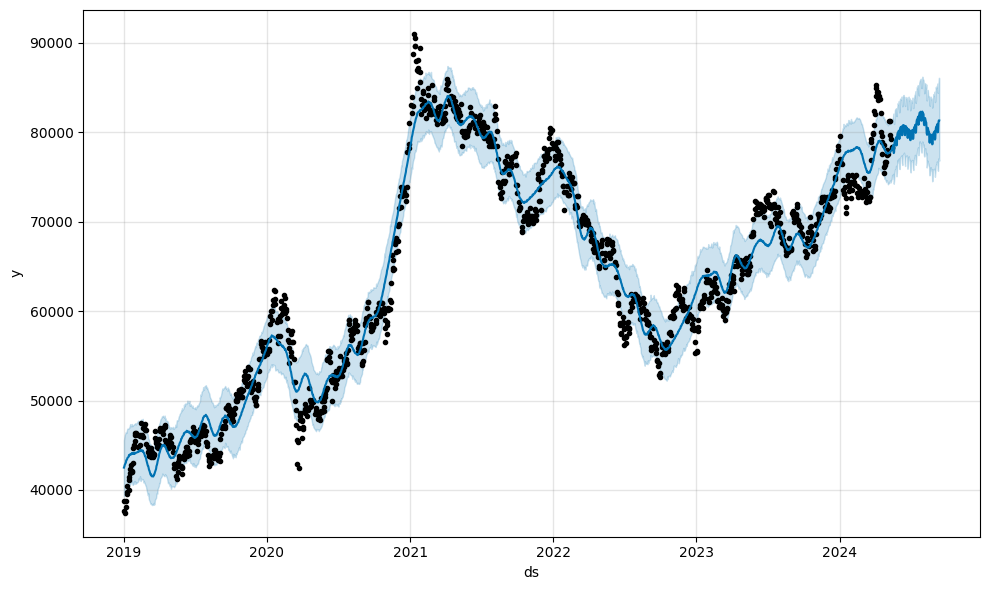

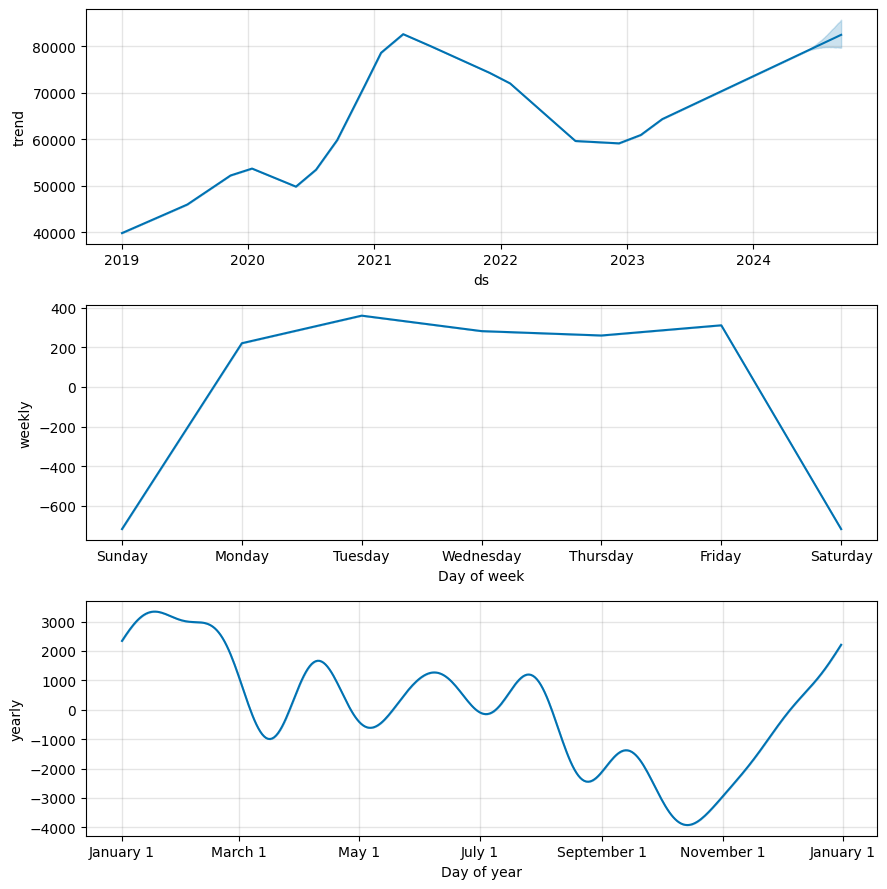

In [51]:
# plot the forecasted value
plot(model1, forecastdaily)

# add components of forecasted value
plot_components(model1, forecastdaily)

# show the plot
plt.show()

## Evaluating the Model 

After forecasting the close price, we can evaluate the model. The difference between forecasted value and real value will calculated and used to determine how good the model

In [66]:
# forecast and real value using cross validation 
dailyclose_cv = cross_validation(model1, initial="1095 days", period="180 days", horizon="30 days")

# evaluate the cv value
dailyclose_cv = performance_metrics(dailyclose_cv)

# funtion for evalutaing model  
# MAE (<eam Absolute Error)
def mean_absolute_error(real_value, forecasted_value) -> float :
    abs_resid = [abs(f-r) for r,f in zip(real_value, forecasted_value)]
    return mean(abs_resid)

# MSE (Mean Squared Error)
def mean_squared_error(real_value, forecasted_value) -> float :
    squ_resid = [(f-r)**2 for r,f in zip(real_value, forecasted_value)]
    return mean(squ_resid)

# RMSE (Root Mean Squared Error)
def root_mean_squared_error(real_value, forecasted_value) -> float :
    squ_resid = [(f-r)**2 for r,f in zip(real_value, forecasted_value)]
    return np.sqrt(mean(squ_resid)) 

# calculate mae, mse, rmse 
#mae1 = mean_absolute_error(dailyclose_cv["y"], dailyclose_cv["yhat"])
#mse1 = mean_squared_error(dailyclose_cv["y"], dailyclose_cv["yhat"])
#rmae1 = root_mean_absolute_error(dailyclose_cv["y"], dailyclose_cv["yhat"])


# calculate MAE, MSE, RMSE 
print("Mean Abslolute Error : {:.2f}".format(mae1))
print("Mean Squared Error : {:.2f}".format(mae1))
print("Root Mean Squared Error : {:.2f}".format(mae1))

  0%|          | 0/5 [00:00<?, ?it/s]

13:02:59 - cmdstanpy - INFO - Chain [1] start processing
13:02:59 - cmdstanpy - INFO - Chain [1] done processing
13:03:00 - cmdstanpy - INFO - Chain [1] start processing
13:03:00 - cmdstanpy - INFO - Chain [1] done processing
13:03:01 - cmdstanpy - INFO - Chain [1] start processing
13:03:01 - cmdstanpy - INFO - Chain [1] done processing
13:03:02 - cmdstanpy - INFO - Chain [1] start processing
13:03:02 - cmdstanpy - INFO - Chain [1] done processing
13:03:03 - cmdstanpy - INFO - Chain [1] start processing
13:03:04 - cmdstanpy - INFO - Chain [1] done processing


KeyError: 'y'

## Hyperparameter Tuning

Hyperparameter tuning is one method to find/decide what is the best parameter(s) for the model. The best parameter(s) is/are parameter(s) that will make the minimum error. The hyperparameter tuning will be done using Grid SearchCV

In [ ]:
params_grid = {
    "seasonality_par" : ["additive", "multiplicative"], 
    "changepoint_prior_scale" : [0.01, 0.05, 0.1, 0.5]
    "seasonality_prior_scale" : [1, 5, 10, 20, 30], 
}

best_param = []
best_score = 0

for mode in param_grid['seasonality_par']:
    for cps in param_grid['changepoint_prior_scale']:
        for sps in param_grid['seasonality_prior_scale']:
            # Create a model with the current hyperparameters
            model = Prophet(seasonality_mode=mode, changepoint_prior_scale=cps, seasonality_prior_scale=sps)
            model.fit(data)

            # Evaluate the model using Mean Absolute Error (MAE)
            score = evaluate_model(model, mean_absolute_error)

            # Update best parameters if necessary
            if score < best_score:
                best_score = score
                best_params = {
                    'seasonality_mode': mode,
                    'changepoint_prior_scale': cps,
                    'seasonality_prior_scale': sps
                }

print(best_params)
print(best_score)

# Create the best model with the optimal hyperparameters
best_model = Prophet(**best_params)
best_model.fit(data)

# Reference 

*https://machinelearningmastery.com/decompose-time-series-data-trend-seasonality/*  

*https://www.geeksforgeeks.org/plot-ohlc-charts-with-python/* 

*https://facebook.github.io/prophet/docs/quick_start.html* 

*https://www.kaggle.com/code/prashant111/tutorial-time-series-forecasting-with-prophet* 

*https://machinelearningmastery.com/time-series-forecasting-with-prophet-in-python/*

*https://martinxpn.medium.com/time-series-analysis-with-python-using-prophet-98-100-days-of-python-689b26e8e222*